In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import quimb.tensor as qtn

In [2]:
def random_clifford_t_block(qc, q1, q2, add_t, p_t=0.2):
    for q in [q1, q2]:
        r = np.random.randint(4)
        if r == 0:
            qc.h(q)
        elif r == 1:
            qc.s(q)
        elif r == 2:
            qc.h(q)
            qc.s(q)

    if np.random.rand() < 0.5:
        qc.cx(q1, q2)
    else:
        qc.cx(q2, q1)

    if add_t:
        if np.random.rand() < p_t:
            qc.t(q1)
        if np.random.rand() < p_t:
            qc.t(q2)


def build_circuit_2d(Lx, Ly, d, add_t, p_t=0.2, max_bond=64, cutoff=1e-10):
    """Builds the circuit as a quimb CircuitMPS — never materializes the full 2^N state."""
    N = Lx * Ly
    qc = qtn.CircuitMPS(N, max_bond=max_bond, cutoff=cutoff)

    def idx(x, y):
        return y * Lx + x

    for layer in range(d):
        direction = layer % 2
        offset = (layer // 2) % 2

        if direction == 0:
            for y in range(Ly):
                for x in range(offset, Lx - 1, 2):
                    random_clifford_t_block(qc, idx(x, y), idx(x + 1, y), add_t=add_t, p_t=p_t)
        else:
            for x in range(Lx):
                for y in range(offset, Ly - 1, 2):
                    random_clifford_t_block(qc, idx(x, y), idx(x, y + 1), add_t=add_t, p_t=p_t)

    return qc


def exact_projected_cp(qc, n_measured):
    """
    Computes the projected ensemble collision probability:

        2^N * |<0|psi>|^4 / p_{0|psi}^2

    where x = outcome on the n_measured rightmost qubits (measured subsystem)
          y = outcome on the remaining n_projected qubits (projected subsystem)
          N = n_measured + n_projected (total qubits)
    """
    N = qc.N

    amp = qc.amplitude('0' * N)
    p_all_zeros = abs(amp) ** 2

    measured_qubits = list(range(n_measured))
    marginal = qc.compute_marginal(where=measured_qubits)
    p_x0 = marginal[(0,) * n_measured]

    denom = p_x0 ** 2
    if not np.isfinite(denom) or denom <= 0:
        return np.nan

    return (2 ** N) * p_all_zeros ** 2 / denom

L=2, N=4, n_measured=2, n_projected=2, dropped 0/20 samples (p_x0=0)
  saved exact_cp_d10_upto_N4.png


c:\Users\Daniel\Desktop\research\.venv\Lib\site-packages\cotengra\hyperoptimizers\hyper.py:36: UserWarning: Couldn't import `kahypar` - skipping from default hyper optimizer and using basic `labels` method instead. `kahypar` is highly recommended for the best quality contraction paths.
  warnings.warn(


L=3, N=9, n_measured=4, n_projected=5, dropped 0/20 samples (p_x0=0)
  saved exact_cp_d10_upto_N9.png
L=4, N=16, n_measured=8, n_projected=8, dropped 0/20 samples (p_x0=0)
  saved exact_cp_d10_upto_N16.png


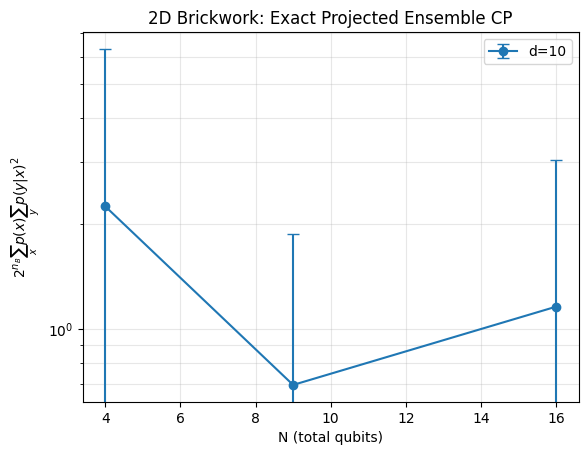

In [3]:
# Vary N, fixed depth
# Statevector is feasible up to ~N=25 (L=5); memory doubles with each qubit
L_values = list(range(2, 5))   # N = 4, 9, 16, 25
d = 10
add_t = True
samples_per_n = 20
output_dir = "results/exact_mps"
os.makedirs(output_dir, exist_ok=True)

avg_prob, std_prob, total_qubits = [], [], []

for L in L_values:
    N = L * L
    n_measured = N // 2
    n_projected = N - n_measured
    vals = []

    for _ in range(samples_per_n):
        qc = build_circuit_2d(L, L, d, add_t, p_t=0.15)
        vals.append(exact_projected_cp(qc, n_measured))

    n_dropped = int(np.sum(np.isnan(vals)))
    print(f"L={L}, N={N}, n_measured={n_measured}, n_projected={n_projected}, dropped {n_dropped}/{samples_per_n} samples (p_x0=0)")

    avg_prob.append(np.nanmean(vals))
    std_prob.append(np.nanstd(vals))
    total_qubits.append(N)

    fig, ax = plt.subplots()
    ax.errorbar(total_qubits, avg_prob, yerr=std_prob, marker='o', capsize=4, label=f"d={d}")
    ax.set_xlabel("N (total qubits)")
    ax.set_ylabel(r"$2^{n_B} \sum_x p(x) \sum_y p(y|x)^2$")
    ax.set_yscale('log')
    ax.set_title(f"2D Brickwork: Exact Projected Ensemble CP")
    ax.grid(True, which='both', alpha=0.3)
    ax.legend()
    fig.savefig(os.path.join(output_dir, f"exact_cp_d{d}_upto_N{N}.png"), dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f"  saved exact_cp_d{d}_upto_N{N}.png")

plt.errorbar(total_qubits, avg_prob, yerr=std_prob, marker='o', capsize=4, label=f"d={d}")
plt.xlabel("N (total qubits)")
plt.ylabel(r"$2^{n_B} \sum_x p(x) \sum_y p(y|x)^2$")
plt.yscale('log')
plt.title(f"2D Brickwork: Exact Projected Ensemble CP")
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.show()

d=1, N=25, n_measured=12, n_projected=13, dropped 0/20 samples (p_x0=0)
  saved exact_cp_N25_upto_d1.png
d=2, N=25, n_measured=12, n_projected=13, dropped 1/20 samples (p_x0=0)
  saved exact_cp_N25_upto_d2.png
d=3, N=25, n_measured=12, n_projected=13, dropped 3/20 samples (p_x0=0)
  saved exact_cp_N25_upto_d3.png
d=4, N=25, n_measured=12, n_projected=13, dropped 0/20 samples (p_x0=0)
  saved exact_cp_N25_upto_d4.png
d=5, N=25, n_measured=12, n_projected=13, dropped 1/20 samples (p_x0=0)
  saved exact_cp_N25_upto_d5.png
d=6, N=25, n_measured=12, n_projected=13, dropped 4/20 samples (p_x0=0)
  saved exact_cp_N25_upto_d6.png
d=7, N=25, n_measured=12, n_projected=13, dropped 0/20 samples (p_x0=0)
  saved exact_cp_N25_upto_d7.png
d=8, N=25, n_measured=12, n_projected=13, dropped 1/20 samples (p_x0=0)
  saved exact_cp_N25_upto_d8.png


c:\Users\Daniel\Desktop\research\.venv\Lib\site-packages\quimb\tensor\decomp.py:1028: UserWarning: Got: Internal algorithm failed to converge., falling back to scipy gesvd driver.
  warnings.warn(f"Got: {e}, falling back to scipy gesvd driver.")


d=9, N=25, n_measured=12, n_projected=13, dropped 3/20 samples (p_x0=0)
  saved exact_cp_N25_upto_d9.png
d=10, N=25, n_measured=12, n_projected=13, dropped 0/20 samples (p_x0=0)
  saved exact_cp_N25_upto_d10.png
d=11, N=25, n_measured=12, n_projected=13, dropped 0/20 samples (p_x0=0)
  saved exact_cp_N25_upto_d11.png
d=12, N=25, n_measured=12, n_projected=13, dropped 0/20 samples (p_x0=0)
  saved exact_cp_N25_upto_d12.png
d=13, N=25, n_measured=12, n_projected=13, dropped 0/20 samples (p_x0=0)
  saved exact_cp_N25_upto_d13.png
d=14, N=25, n_measured=12, n_projected=13, dropped 0/20 samples (p_x0=0)
  saved exact_cp_N25_upto_d14.png
d=15, N=25, n_measured=12, n_projected=13, dropped 0/20 samples (p_x0=0)
  saved exact_cp_N25_upto_d15.png
d=16, N=25, n_measured=12, n_projected=13, dropped 0/20 samples (p_x0=0)
  saved exact_cp_N25_upto_d16.png
d=17, N=25, n_measured=12, n_projected=13, dropped 0/20 samples (p_x0=0)
  saved exact_cp_N25_upto_d17.png
d=18, N=25, n_measured=12, n_projected=

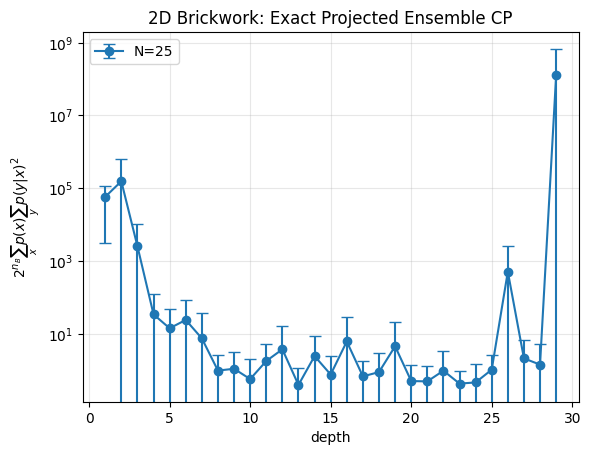

In [4]:
# Vary depth, fixed N
L = 5
d_values = list(range(1, 30))
add_t = True
samples_per_d = 20
output_dir = "results/exact_mps"
os.makedirs(output_dir, exist_ok=True)

N = L * L
n_measured = N // 2
n_projected = N - n_measured

avg_prob, std_prob, completed_depths = [], [], []

for d in d_values:
    vals = []

    for _ in range(samples_per_d):
        qc = build_circuit_2d(L, L, d, add_t, p_t=0.15)
        vals.append(exact_projected_cp(qc, n_measured))

    n_dropped = int(np.sum(np.isnan(vals)))
    print(f"d={d}, N={N}, n_measured={n_measured}, n_projected={n_projected}, dropped {n_dropped}/{samples_per_d} samples (p_x0=0)")

    avg_prob.append(np.nanmean(vals))
    std_prob.append(np.nanstd(vals))
    completed_depths.append(d)

    fig, ax = plt.subplots()
    ax.errorbar(completed_depths, avg_prob, yerr=std_prob, marker='o', capsize=4, label=f"N={N}")
    ax.set_xlabel("depth")
    ax.set_ylabel(r"$2^{n_B} \sum_x p(x) \sum_y p(y|x)^2$")
    ax.set_yscale('log')
    ax.set_title(f"2D Brickwork: Exact Projected Ensemble CP")
    ax.grid(True, which='both', alpha=0.3)
    ax.legend()
    fig.savefig(os.path.join(output_dir, f"exact_cp_N{N}_upto_d{d}.png"), dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f"  saved exact_cp_N{N}_upto_d{d}.png")

plt.errorbar(completed_depths, avg_prob, yerr=std_prob, marker='o', capsize=4, label=f"N={N}")
plt.xlabel("depth")
plt.ylabel(r"$2^{n_B} \sum_x p(x) \sum_y p(y|x)^2$")
plt.yscale('log')
plt.title(f"2D Brickwork: Exact Projected Ensemble CP")
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.show()